In [1]:
import os
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from datetime import datetime, timedelta
from functools import reduce
from math import radians, sin, cos, sqrt, atan2
import matplotlib.pyplot as plt

from pyspark.sql.types import IntegerType, BooleanType, StringType, DoubleType

In [2]:
spark = SparkSession.builder \
    .appName("final-applications-gen") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "200") \
    .getOrCreate()

26/01/19 00:12:02 WARN Utils: Your hostname, Lianas-MacBook-Pro.local resolves to a loopback address: 127.0.0.1; using 192.168.20.123 instead (on interface en0)
26/01/19 00:12:02 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/19 00:12:02 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


# Task 1 - Applications Data Processing

I'm working with daily logs split across multiple datasets: sessions, applications, hardware, updateEvents, and users. The goal is to build a state table that tracks each user-device combination over time, then run aggregations and data quality checks.


In [3]:
path1 = "data/applications-gen_raw"
print("Subfolders:", os.listdir(path1)[:10])

Subfolders: ['hardware', '.DS_Store', 'sessions', 'users', 'applications', 'updateEvents']


In [4]:
days = sorted([d for d in os.listdir(f"{path1}/sessions") if d.startswith("2025-")])
print("Detected days:", days)

Detected days: ['2025-12-03', '2025-12-04', '2025-12-05', '2025-12-06', '2025-12-07', '2025-12-08', '2025-12-09']


7 days to process. Building a system to handle these sequentially while keeping historical state.


## Enricher


### a. Create a day-0 state for a userDevice table

For registerTs and lastActivityTs, I need timestamps from ALL datasets combined - sessions, updateEvents, applications, hardware, and users. This ensures we capture the first and last time each user-device was detected across any source.

In [5]:
day0 = days[0]
print("Day-0:", day0)

Day-0: 2025-12-03


In [6]:
# Load all datasets for day-0
sessions_day0 = spark.read.parquet(f"{path1}/sessions/{day0}")
applications_day0 = spark.read.parquet(f"{path1}/applications/{day0}")
hardware_day0 = spark.read.parquet(f"{path1}/hardware/{day0}")
updateEvents_day0 = spark.read.parquet(f"{path1}/updateEvents/{day0}")
users_day0 = spark.read.parquet(f"{path1}/users/{day0}")

In [7]:
# 1. Extract timestamps from Sessions (has userId, deviceId, and precise timestamps)
sessions_ts = sessions_day0.select(
    F.col("userid").alias("userId"),
    F.col("deviceid").alias("deviceId"),
    F.col("serverTs").alias("timestamp")
)

print(f"Sessions timestamps: {sessions_ts.count()}")
sessions_ts.show(3, truncate=False, vertical=True)

Sessions timestamps: 20000
-RECORD 0------------------------
 userId    | user_1196           
 deviceId  | device_1285         
 timestamp | 2025-12-03 23:50:23 
-RECORD 1------------------------
 userId    | user_2370           
 deviceId  | device_3997         
 timestamp | 2025-12-03 16:01:18 
-RECORD 2------------------------
 userId    | user_24             
 deviceId  | device_4903         
 timestamp | 2025-12-03 23:30:36 
only showing top 3 rows



In [8]:
# 2. Extract timestamps from UpdateEvents (has deviceId and event timestamps)
updateEvents_ts = updateEvents_day0.select(
    F.lit(None).cast("string").alias("userId"),
    F.col("deviceid").alias("deviceId"),
    F.col("eventTs").alias("timestamp")
)

print(f"UpdateEvents timestamps: {updateEvents_ts.count()}")
updateEvents_ts.show(3, truncate=False, vertical=True)

UpdateEvents timestamps: 10392
-RECORD 0------------------------
 userId    | NULL                
 deviceId  | device_3644         
 timestamp | 2025-12-03 01:16:17 
-RECORD 1------------------------
 userId    | NULL                
 deviceId  | device_2781         
 timestamp | 2025-12-03 09:52:33 
-RECORD 2------------------------
 userId    | NULL                
 deviceId  | device_2781         
 timestamp | 2025-12-03 17:18:38 
only showing top 3 rows



In [9]:
# 3. Extract timestamps from Applications (use day start as proxy)
applications_ts = applications_day0.select(
    F.lit(None).cast("string").alias("userId"),
    F.col("deviceid").alias("deviceId"),
    F.lit(f"{day0} 00:00:00").cast("timestamp").alias("timestamp")
).distinct()

print(f"Applications timestamps: {applications_ts.count()}")
applications_ts.show(3, truncate=False, vertical=True)

Applications timestamps: 3500
-RECORD 0------------------------
 userId    | NULL                
 deviceId  | device_3781         
 timestamp | 2025-12-03 00:00:00 
-RECORD 1------------------------
 userId    | NULL                
 deviceId  | device_4801         
 timestamp | 2025-12-03 00:00:00 
-RECORD 2------------------------
 userId    | NULL                
 deviceId  | device_3919         
 timestamp | 2025-12-03 00:00:00 
only showing top 3 rows



In [10]:
# 4. Extract timestamps from Hardware (use day start as proxy)
hardware_ts = hardware_day0.select(
    F.lit(None).cast("string").alias("userId"),
    F.col("deviceid").alias("deviceId"),
    F.lit(f"{day0} 00:00:00").cast("timestamp").alias("timestamp")
).distinct()

print(f"Hardware timestamps: {hardware_ts.count()}")
hardware_ts.show(3, truncate=False, vertical=True)

Hardware timestamps: 3500
-RECORD 0------------------------
 userId    | NULL                
 deviceId  | device_3781         
 timestamp | 2025-12-03 00:00:00 
-RECORD 1------------------------
 userId    | NULL                
 deviceId  | device_281          
 timestamp | 2025-12-03 00:00:00 
-RECORD 2------------------------
 userId    | NULL                
 deviceId  | device_1244         
 timestamp | 2025-12-03 00:00:00 
only showing top 3 rows



In [11]:
# 5. Extract timestamps from Users (link to devices via sessions)
# First, get userId-deviceId pairs from sessions
user_devices_from_sessions = sessions_day0.select(
    F.col("userid").alias("userId"),
    F.col("deviceid").alias("deviceId")
).distinct()

print(f"User-device pairs from sessions: {user_devices_from_sessions.count()}")

User-device pairs from sessions: 19989


In [12]:
# Then join users with their devices
users_ts = users_day0.select(
    F.col("userid").alias("userId")
).distinct().join(
    user_devices_from_sessions,
    on="userId",
    how="inner"
).select(
    "userId",
    "deviceId",
    F.lit(f"{day0} 00:00:00").cast("timestamp").alias("timestamp")
)

print(f"Users timestamps: {users_ts.count()}")
users_ts.show(3, truncate=False, vertical=True)

Users timestamps: 14018
-RECORD 0------------------------
 userId    | user_1982           
 deviceId  | device_2700         
 timestamp | 2025-12-03 00:00:00 
-RECORD 1------------------------
 userId    | user_2336           
 deviceId  | device_2866         
 timestamp | 2025-12-03 00:00:00 
-RECORD 2------------------------
 userId    | user_380            
 deviceId  | device_1345         
 timestamp | 2025-12-03 00:00:00 
only showing top 3 rows



In [13]:
# Summary of all timestamp sources
print("Timestamp counts from all 5 datasets:")
print(f"  Sessions:      {sessions_ts.count():>6}")
print(f"  UpdateEvents:  {updateEvents_ts.count():>6}")
print(f"  Applications:  {applications_ts.count():>6}")
print(f"  Hardware:      {hardware_ts.count():>6}")
print(f"  Users:         {users_ts.count():>6}")

Timestamp counts from all 5 datasets:
  Sessions:       20000
  UpdateEvents:   10392
  Applications:    3500
  Hardware:        3500
  Users:          14018


In [14]:
# Union all 5 timestamp sources
all_timestamps = sessions_ts \
    .union(updateEvents_ts) \
    .union(applications_ts) \
    .union(hardware_ts) \
    .union(users_ts)

print(f"All timestamps from day-0 (ALL datasets): {all_timestamps.count()}")
all_timestamps.show(10, truncate=False, vertical=True)

All timestamps from day-0 (ALL datasets): 51410


-RECORD 0------------------------
 userId    | user_1196           
 deviceId  | device_1285         
 timestamp | 2025-12-03 23:50:23 
-RECORD 1------------------------
 userId    | user_2370           
 deviceId  | device_3997         
 timestamp | 2025-12-03 16:01:18 
-RECORD 2------------------------
 userId    | user_24             
 deviceId  | device_4903         
 timestamp | 2025-12-03 23:30:36 
-RECORD 3------------------------
 userId    | user_536            
 deviceId  | device_439          
 timestamp | 2025-12-05 03:12:45 
-RECORD 4------------------------
 userId    | user_3466           
 deviceId  | device_350          
 timestamp | 2025-12-03 08:28:30 
-RECORD 5------------------------
 userId    | user_2572           
 deviceId  | device_4481         
 timestamp | 2025-12-03 05:16:32 
-RECORD 6------------------------
 userId    | user_3436           
 deviceId  | device_2184         
 timestamp | 2025-12-03 08:20:58 
-RECORD 7------------------------
 userId    | u

Got 50k+ timestamps combined. Now aggregating by user-device.

In [15]:
# Compute registerTs and lastActivityTs per user-device from ALL sources
user_device_timestamps = all_timestamps.groupBy("userId", "deviceId").agg(
    F.min("timestamp").alias("registerTs"),
    F.max("timestamp").alias("lastActivityTs")
)

print(f"User-Device pairs: {user_device_timestamps.count()}")
user_device_timestamps.show(5, truncate=False, vertical=True)

User-Device pairs: 23489


-RECORD 0-----------------------------
 userId         | user_3871           
 deviceId       | device_2453         
 registerTs     | 2025-12-03 20:46:10 
 lastActivityTs | 2025-12-03 20:46:10 
-RECORD 1-----------------------------
 userId         | user_1982           
 deviceId       | device_2700         
 registerTs     | 2025-12-03 00:00:00 
 lastActivityTs | 2025-12-03 09:11:47 
-RECORD 2-----------------------------
 userId         | user_2336           
 deviceId       | device_2866         
 registerTs     | 2025-12-03 00:00:00 
 lastActivityTs | 2025-12-03 23:27:49 
-RECORD 3-----------------------------
 userId         | user_4870           
 deviceId       | device_2448         
 registerTs     | 2025-12-05 05:06:31 
 lastActivityTs | 2025-12-05 05:06:31 
-RECORD 4-----------------------------
 userId         | user_380            
 deviceId       | device_1345         
 registerTs     | 2025-12-03 00:00:00 
 lastActivityTs | 2025-12-03 05:50:47 
only showing top 5 rows



23,489 user-device pairs detected. Some have userId as null - those are from updateEvents which only track device-level activity. Keeping them since they still provide useful device info.

Next step: joining with session timestamps and snapshots.


In [16]:
# Compute lastSessionTs from sessions only
last_session_ts = sessions_day0.groupBy("userid", "deviceid").agg(
    F.max("serverTs").alias("lastSessionTs")
).withColumnRenamed("userid", "userId").withColumnRenamed("deviceid", "deviceId")

# Get latest snapshots
applications_snapshot = applications_day0.select(
    F.col("deviceid").alias("deviceId"),
    F.col("installedApps").alias("applications")
)

hardware_snapshot = hardware_day0.select(
    F.col("deviceid").alias("deviceId"),
    F.struct(
        F.col("cpu"),
        F.col("ramGb").cast("double").alias("ramGb"),
        F.col("os"),
        F.col("formFactor").alias("deviceType")
    ).alias("hardware")
)

In [17]:
# Build the final day-0 userDevice table
userDevice_day0 = (
    user_device_timestamps
    .join(last_session_ts, on=["userId", "deviceId"], how="left")
    .join(applications_snapshot, on="deviceId", how="left")
    .join(hardware_snapshot, on="deviceId", how="left")
    .select("userId", "deviceId", "registerTs", "lastActivityTs",
            "lastSessionTs", "applications", "hardware")
)

print(f"Day-0 userDevice rows: {userDevice_day0.count()}")
userDevice_day0.show(5, truncate=False, vertical=True)

Day-0 userDevice rows: 23489
-RECORD 0------------------------------------------------------------------------------------------------------
 userId         | user_3871                                                                                    
 deviceId       | device_2453                                                                                  
 registerTs     | 2025-12-03 20:46:10                                                                          
 lastActivityTs | 2025-12-03 20:46:10                                                                          
 lastSessionTs  | 2025-12-03 20:46:10                                                                          
 applications   | NULL                                                                                         
 hardware       | NULL                                                                                         
-RECORD 1------------------------------------------------------------------

Interesting - some devices have NULL applications and hardware, while others have complete data. This probably means not all devices have snapshots captured yet. The NULL userId entries are from update events only.

Day-0 baseline is ready - 23,489 rows.

### b. Create enrich_user_device() function

Using union+window pattern to combine historical state with today's state. This avoids the complexity of joins and cleanly handles: earliest registerTs (first()), latest everything else (last()).

In [18]:
def extract_timestamps_from_all_sources(sessions_df, applications_df, hardware_df, updateEvents_df, users_df, day):
    # Extract timestamps from all 5 datasets.
    # Returns a unified DataFrame with userId, deviceId, timestamp.

    # 1. Sessions - has precise timestamps
    sessions_ts = sessions_df.select(
        F.col("userid").alias("userId"),
        F.col("deviceid").alias("deviceId"),
        F.col("serverTs").alias("timestamp")
    )

    # 2. UpdateEvents - has event timestamps
    updateEvents_ts = updateEvents_df.select(
        F.lit(None).cast("string").alias("userId"),
        F.col("deviceid").alias("deviceId"),
        F.col("eventTs").alias("timestamp")
    )

    # 3. Applications - use day start as proxy
    applications_ts = applications_df.select(
        F.lit(None).cast("string").alias("userId"),
        F.col("deviceid").alias("deviceId"),
        F.lit(f"{day} 00:00:00").cast("timestamp").alias("timestamp")
    ).distinct()

    # 4. Hardware - use day start as proxy
    hardware_ts = hardware_df.select(
        F.lit(None).cast("string").alias("userId"),
        F.col("deviceid").alias("deviceId"),
        F.lit(f"{day} 00:00:00").cast("timestamp").alias("timestamp")
    ).distinct()

    # 5. Users - link to devices via sessions
    user_devices = sessions_df.select(
        F.col("userid").alias("userId"),
        F.col("deviceid").alias("deviceId")
    ).distinct()

    users_ts = users_df.select(
        F.col("userid").alias("userId")
    ).distinct().join(
        user_devices,
        on="userId",
        how="inner"
    ).select(
        "userId",
        "deviceId",
        F.lit(f"{day} 00:00:00").cast("timestamp").alias("timestamp")
    )

    # Union all 5 sources
    all_timestamps = sessions_ts \
        .union(updateEvents_ts) \
        .union(applications_ts) \
        .union(hardware_ts) \
        .union(users_ts)

    return all_timestamps

In [19]:
def build_daily_state(timestamps_df, sessions_df, applications_df, hardware_df, day):
    # Build complete state for a single day.
    # Returns DataFrame with all userDevice fields plus state_date.
    # Aggregate timestamps per user-device
    user_device_timestamps = timestamps_df.groupBy("userId", "deviceId").agg(
        F.min("timestamp").alias("registerTs"),
        F.max("timestamp").alias("lastActivityTs")
    )

    # Get lastSessionTs from sessions
    last_session_ts = sessions_df.groupBy("userid", "deviceid").agg(
        F.max("serverTs").alias("lastSessionTs")
    ).withColumnRenamed("userid", "userId") \
     .withColumnRenamed("deviceid", "deviceId")

    # Get application snapshots
    apps_snapshot = applications_df.select(
        F.col("deviceid").alias("deviceId"),
        F.col("installedApps").alias("applications")
    )

    # Get hardware snapshots
    hw_snapshot = hardware_df.select(
        F.col("deviceid").alias("deviceId"),
        F.struct(
            F.col("cpu"),
            F.col("ramGb").cast("double").alias("ramGb"),
            F.col("os"),
            F.col("formFactor").alias("deviceType")
        ).alias("hardware")
    )

    # Combine everything
    daily_state = (
        user_device_timestamps
        .join(last_session_ts, on=["userId", "deviceId"], how="left")
        .join(apps_snapshot, on="deviceId", how="left")
        .join(hw_snapshot, on="deviceId", how="left")
        .select("userId", "deviceId", "registerTs", "lastActivityTs",
                "lastSessionTs", "applications", "hardware")
        .withColumn("state_date", F.lit(day))
    )

    return daily_state

In [20]:
def apply_window_aggregations(combined_df):
    # Apply window functions to get earliest registerTs and latest everything else.
    # Returns final state with one row per user-device.
    # Window: partition by user-device, order by date
    w_full = Window.partitionBy("userId", "deviceId").orderBy("state_date") \
        .rowsBetween(Window.unboundedPreceding, Window.unboundedFollowing)

    # Apply window functions
    result = combined_df.withColumn(
        "registerTs_final", F.first("registerTs", ignorenulls=True).over(w_full)
    ).withColumn(
        "lastActivityTs_final", F.last("lastActivityTs", ignorenulls=True).over(w_full)
    ).withColumn(
        "lastSessionTs_final", F.last("lastSessionTs", ignorenulls=True).over(w_full)
    ).withColumn(
        "applications_final", F.last("applications", ignorenulls=True).over(w_full)
    ).withColumn(
        "hardware_final", F.last("hardware", ignorenulls=True).over(w_full)
    )

    # Keep only latest state per user-device
    w_rank = Window.partitionBy("userId", "deviceId").orderBy(F.desc("state_date"))
    final_state = result.withColumn("rank", F.row_number().over(w_rank)) \
        .filter(F.col("rank") == 1) \
        .select(
            "userId", "deviceId",
            F.col("registerTs_final").alias("registerTs"),
            F.col("lastActivityTs_final").alias("lastActivityTs"),
            F.col("lastSessionTs_final").alias("lastSessionTs"),
            F.col("applications_final").alias("applications"),
            F.col("hardware_final").alias("hardware")
        )

    return final_state

In [21]:
def enrich_user_device(prev_state, base_path, day):
    # Main function: Update userDevice state using union+window pattern.
    # Combines yesterday's state with today's data.
    print(f"Processing day: {day}")

    # Step 1: Load today's raw data
    sessions_today = spark.read.parquet(f"{base_path}/sessions/{day}")
    applications_today = spark.read.parquet(f"{base_path}/applications/{day}")
    hardware_today = spark.read.parquet(f"{base_path}/hardware/{day}")
    updateEvents_today = spark.read.parquet(f"{base_path}/updateEvents/{day}")
    users_today = spark.read.parquet(f"{base_path}/users/{day}")

    # Step 2: Extract timestamps from all sources
    all_timestamps_today = extract_timestamps_from_all_sources(
        sessions_today, applications_today, hardware_today,
        updateEvents_today, users_today, day
    )

    # Step 3: Build today's complete state
    today_state = build_daily_state(
        all_timestamps_today, sessions_today,
        applications_today, hardware_today, day
    )

    # Step 4: Add date to previous state
    yesterday = (datetime.strptime(day, "%Y-%m-%d") - timedelta(days=1)).strftime("%Y-%m-%d")
    prev_state_with_date = prev_state.withColumn("state_date", F.lit(yesterday))

    # Step 5: Union yesterday and today (union+window pattern, not join!)
    combined = prev_state_with_date.union(today_state)

    # Step 6: Apply window aggregations to get final state
    final_state = apply_window_aggregations(combined)

    print(f"Final state count: {final_state.count()}")
    return final_state

In [22]:
# Process all days
current_state = userDevice_day0

for day in days[1:]:
    current_state = enrich_user_device(current_state, path1, day)

print(f"Final userDevice state: {current_state.count()} rows")
current_state.filter(F.col("applications").isNotNull()).show(5, truncate=False, vertical=True)

Processing day: 2025-12-04


Final state count: 44514
Processing day: 2025-12-05


Final state count: 64791
Processing day: 2025-12-06


Final state count: 84823
Processing day: 2025-12-07


Final state count: 104796
Processing day: 2025-12-08


Final state count: 124715
Processing day: 2025-12-09


Final state count: 144613


Final userDevice state: 144613 rows


-RECORD 0--------------------------------------------------------------------------------------------------------------
 userId         | NULL                                                                                                 
 deviceId       | device_1019                                                                                          
 registerTs     | 2025-12-03 00:00:00                                                                                  
 lastActivityTs | 2025-12-09 22:49:50                                                                                  
 lastSessionTs  | NULL                                                                                                 
 applications   | {PyCharm -> 1.0, Photoshop -> 1.0, Steam -> 1.0}                                                     
 hardware       | {Intel i7, 16.0, Linux, Desktop}                                                                     
-RECORD 1-------------------------------

I've built a state table that evolves across all days. Each user-device has their earliest registration time and most up-to-date information.


## Aggregator

### a. aggregate_total_n_of_users_so_far_daily()

Computing cumulative user count - the running total of everyone who's ever appeared.


In [23]:
# Union all users from all days
all_users_data = []
for day in days:
    users_df = spark.read.parquet(f"{path1}/users/{day}") \
        .select("userid") \
        .distinct() \
        .withColumn("day", F.lit(day))
    all_users_data.append(users_df)

all_users = reduce(lambda df1, df2: df1.union(df2), all_users_data)

print(f"All users across all days: {all_users.count()}")

All users across all days: 24500


In [24]:
# Daily active users
users_per_day = all_users.groupBy("day").agg(
    F.countDistinct("userid").alias("users_detected_today")
).orderBy("day")

print("Users detected each day:")
users_per_day.show(truncate=False, vertical=True)

Users detected each day:


-RECORD 0--------------------------
 day                  | 2025-12-03 
 users_detected_today | 3500       
-RECORD 1--------------------------
 day                  | 2025-12-04 
 users_detected_today | 3500       
-RECORD 2--------------------------
 day                  | 2025-12-05 
 users_detected_today | 3500       
-RECORD 3--------------------------
 day                  | 2025-12-06 
 users_detected_today | 3500       
-RECORD 4--------------------------
 day                  | 2025-12-07 
 users_detected_today | 3500       
-RECORD 5--------------------------
 day                  | 2025-12-08 
 users_detected_today | 3500       
-RECORD 6--------------------------
 day                  | 2025-12-09 
 users_detected_today | 3500       



Exactly 3500 users active every single day. That's suspiciously constant: either the data is capped/sampled, or there's some artificial limit. Real user activity would fluctuate more.

Computing cumulative now.

In [25]:
# Cumulative calculation
user_first_seen = all_users.groupBy("userid").agg(
    F.min("day").alias("first_day")
)

cumulative_results = []
for day in days:
    count = user_first_seen.filter(F.col("first_day") <= day).count()
    cumulative_results.append((day, count))

users_cumulative_df = spark.createDataFrame(cumulative_results, ["day", "total_users_so_far"])

users_aggregated = users_per_day.join(users_cumulative_df, on="day", how="left").orderBy("day")

print("Daily + cumulative users:")
users_aggregated.show(truncate=False, vertical=True)

Daily + cumulative users:


-RECORD 0--------------------------
 day                  | 2025-12-03 
 users_detected_today | 3500       
 total_users_so_far   | 3500       
-RECORD 1--------------------------
 day                  | 2025-12-04 
 users_detected_today | 3500       
 total_users_so_far   | 4533       
-RECORD 2--------------------------
 day                  | 2025-12-05 
 users_detected_today | 3500       
 total_users_so_far   | 4858       
-RECORD 3--------------------------
 day                  | 2025-12-06 
 users_detected_today | 3500       
 total_users_so_far   | 4958       
-RECORD 4--------------------------
 day                  | 2025-12-07 
 users_detected_today | 3500       
 total_users_so_far   | 4986       
-RECORD 5--------------------------
 day                  | 2025-12-08 
 users_detected_today | 3500       
 total_users_so_far   | 4994       
-RECORD 6--------------------------
 day                  | 2025-12-09 
 users_detected_today | 3500       
 total_users_so_far   | 4997

This is interesting. Daily count stays flat at 3,500, but cumulative grows fast at first (3500 -> 4533 -> 4858) then slows down dramatically (4986 -> 4994 -> 4997).

This means:
- Most users appear in the first few days
- By day 6-7, we're seeing almost entirely repeat users
- Only ~1,500 new users across the entire period (4997 total vs 3500 on day 1)
- Strong user retention - same people coming back daily

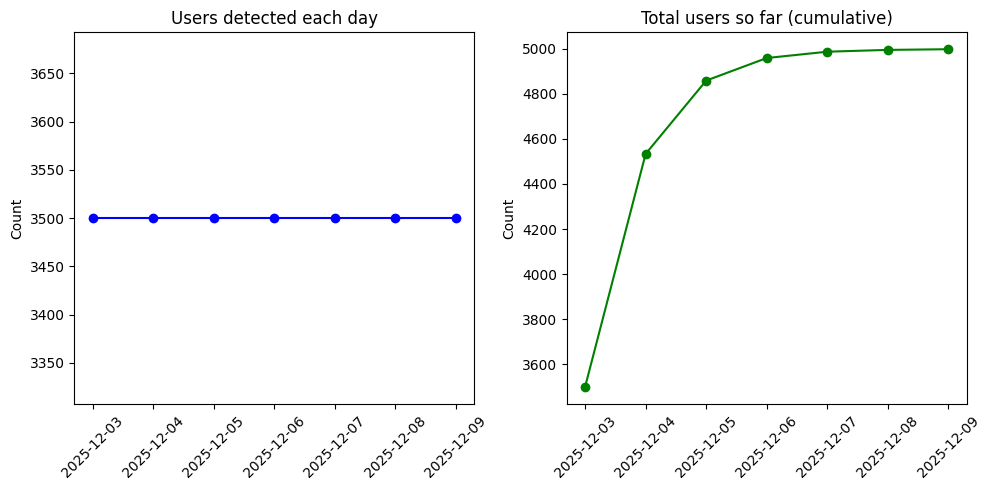

In [26]:
pdf_users = users_aggregated.toPandas()

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(pdf_users["day"], pdf_users["users_detected_today"], marker="o", color="blue")
plt.xticks(rotation=45)
plt.title("Users detected each day")
plt.ylabel("Count")
plt.tight_layout()

plt.subplot(1, 2, 2)
plt.plot(pdf_users["day"], pdf_users["total_users_so_far"], marker="o", color="green")
plt.xticks(rotation=45)
plt.title("Total users so far (cumulative)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

The cumulative curve flattens out quick - most user growth happens in days 1-3, then it plateaus. We're basically seeing the same ~3500 users return every day after the initial signup wave.


### b. aggregate_n_of_installs_uninstalls_daily()

Using union+window+lag pattern to detect day-to-day app changes.


In [27]:
# Union all application snapshots
all_apps_data = []
for day in days:
    apps_df = spark.read.parquet(f"{path1}/applications/{day}") \
        .select("deviceid", "installedApps") \
        .withColumn("day", F.lit(day))
    all_apps_data.append(apps_df)

apps_all = reduce(lambda df1, df2: df1.union(df2), all_apps_data)

print(f"All application snapshots: {apps_all.count()}")
apps_all.show(5, truncate=False, vertical=True)

All application snapshots: 24500
-RECORD 0--------------------------------------------------------------------------------------------------------------------------
 deviceid      | device_4411                                                                                                       
 installedApps | {PyCharm -> 3.1, Illustrator -> 4.0, Outlook -> 4.0, VSCode -> 4.0, Chrome -> 4.0, Photoshop -> 1.0, Edge -> 4.0} 
 day           | 2025-12-03                                                                                                        
-RECORD 1--------------------------------------------------------------------------------------------------------------------------
 deviceid      | device_3013                                                                                                       
 installedApps | {IntelliJ -> 3.1, EpicGames -> 1.0, VSCode -> 1.0, Teams -> 1.0, Edge -> 4.0, Firefox -> 2.0}                     
 day           | 2025-12-03                

24,500 app snapshots total. Each device has its daily app list captured.

In [28]:
# Use window with lag to compare consecutive days
w = Window.partitionBy("deviceid").orderBy("day")

apps_with_prev = apps_all.withColumn(
    "prev_apps",
    F.lag(F.col("installedApps"), 1).over(w)
)

print("Apps with previous day:")
apps_with_prev.show(5, truncate=False, vertical=True)

Apps with previous day:


-RECORD 0---------------------------------------------------------------------------------------------------------
 deviceid      | device_1004                                                                                      
 installedApps | {VSCode -> 3.1, Teams -> 3.1, Chrome -> 2.0, Photoshop -> 3.1, Edge -> 1.0}                      
 day           | 2025-12-03                                                                                       
 prev_apps     | NULL                                                                                             
-RECORD 1---------------------------------------------------------------------------------------------------------
 deviceid      | device_1004                                                                                      
 installedApps | {IntelliJ -> 4.0, PyCharm -> 2.0, Teams -> 4.0, Chrome -> 2.0, Discord -> 3.1, Photoshop -> 3.1} 
 day           | 2025-12-04                                                     

Good - device_1004 shows day-to-day changes. Day 1 has NULL prev_apps (first appearance), then each day shows the previous snapshot. Apps are churning - VSCode/Teams -> IntelliJ -> Illustrator. This device is really active with installs/uninstalls.

Calculating changes per device.

In [29]:
# Detect installs and uninstalls
apps_changes = apps_with_prev.withColumn(
    "installs",
    F.size(F.array_except(
        F.map_keys(F.coalesce(F.col("installedApps"), F.create_map())),
        F.map_keys(F.coalesce(F.col("prev_apps"), F.create_map()))
    ))
).withColumn(
    "uninstalls",
    F.size(F.array_except(
        F.map_keys(F.coalesce(F.col("prev_apps"), F.create_map())),
        F.map_keys(F.coalesce(F.col("installedApps"), F.create_map()))
    ))
)

print("Apps with install/uninstall counts:")
apps_changes.filter(F.col("prev_apps").isNotNull()).show(5, truncate=False, vertical=True)

Apps with install/uninstall counts:


-RECORD 0---------------------------------------------------------------------------------------------------------
 deviceid      | device_1004                                                                                      
 installedApps | {IntelliJ -> 4.0, PyCharm -> 2.0, Teams -> 4.0, Chrome -> 2.0, Discord -> 3.1, Photoshop -> 3.1} 
 day           | 2025-12-04                                                                                       
 prev_apps     | {VSCode -> 3.1, Teams -> 3.1, Chrome -> 2.0, Photoshop -> 3.1, Edge -> 1.0}                      
 installs      | 3                                                                                                
 uninstalls    | 2                                                                                                
-RECORD 1---------------------------------------------------------------------------------------------------------
 deviceid      | device_1004                                                    

device_1004 example: day 2 had 3 installs + 2 uninstalls, day 3 had 1 install + 4 uninstalls (net loss). The array operations are working - detecting what appeared vs what disappeared.

Summing across all devices for daily totals.


In [30]:
# Aggregate by day
daily_installs_uninstalls = apps_changes \
    .filter(F.col("prev_apps").isNotNull()) \
    .groupBy("day").agg(
    F.sum("installs").alias("total_installs"),
    F.sum("uninstalls").alias("total_uninstalls")
).orderBy("day")

print("Daily installs/uninstalls:")
daily_installs_uninstalls.show(truncate=False, vertical=True)

Daily installs/uninstalls:


-RECORD 0----------------------
 day              | 2025-12-04 
 total_installs   | 7937       
 total_uninstalls | 7907       
-RECORD 1----------------------
 day              | 2025-12-05 
 total_installs   | 10194      
 total_uninstalls | 10267      
-RECORD 2----------------------
 day              | 2025-12-06 
 total_installs   | 11060      
 total_uninstalls | 10925      
-RECORD 3----------------------
 day              | 2025-12-07 
 total_installs   | 11225      
 total_uninstalls | 11227      
-RECORD 4----------------------
 day              | 2025-12-08 
 total_installs   | 11167      
 total_uninstalls | 11283      
-RECORD 5----------------------
 day              | 2025-12-09 
 total_installs   | 11289      
 total_uninstalls | 11331      



Interesting pattern:
- Day 2 (2025-12-04): ~8k installs, ~8k uninstalls (nearly balanced)
- Days grow to ~11k both by end of week
- Installs slightly ahead most days, but day 5 had MORE uninstalls than installs (10,194 vs 10,267)
- Day 8-9: uninstalls edge ahead again

This is close to equilibrium - people are churning apps constantly but net change is small.

Visualizing the trend.


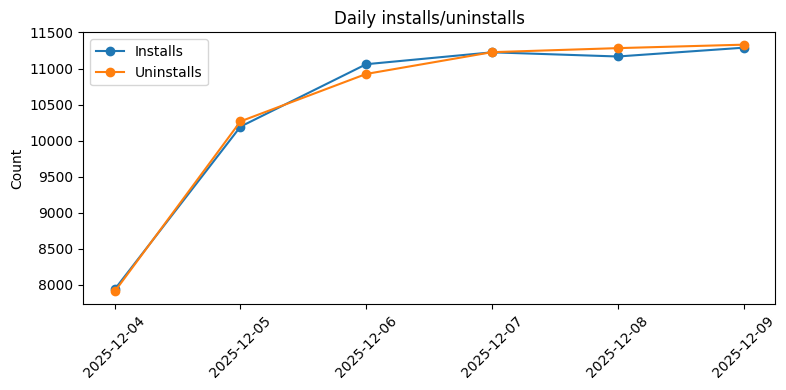

In [31]:
pdf_installs = daily_installs_uninstalls.toPandas()

plt.figure(figsize=(8, 4))
plt.plot(pdf_installs["day"], pdf_installs["total_installs"], marker="o", label="Installs")
plt.plot(pdf_installs["day"], pdf_installs["total_uninstalls"], marker="o", label="Uninstalls")
plt.xticks(rotation=45)
plt.title("Daily installs/uninstalls")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

The lines track super close. Big jump from day 1 to day 2 (8k to 10k), then stabilizes around 11k. After day 4, installs and uninstalls basically match - the app ecosystem is in equilibrium. Users are swapping apps but not growing their collections.

## Data Quality Checks

Three logical cross-dataset checks validating business rules.


In [32]:
dq_day = days[0]
print(f"Running DQ checks for: {dq_day}")

sessions_dq = spark.read.parquet(f"{path1}/sessions/{dq_day}")
apps_dq = spark.read.parquet(f"{path1}/applications/{dq_day}")
hardware_dq = spark.read.parquet(f"{path1}/hardware/{dq_day}")
users_dq = spark.read.parquet(f"{path1}/users/{dq_day}")

Running DQ checks for: 2025-12-03


### Data Quality Check 1: Session App Must Be Installed

A session can't reference an application that isn't installed on the device.

If Chrome appears in sessions but not in installedApps, either:
- Sessions are logged before app snapshots update
- App installation tracking is broken
- There's a timestamp mismatch between datasets

In [33]:
def dq_check_session_app_installed(sessions_df, apps_df):
    # Join sessions with their device's app list
    joined = sessions_df.alias("s").join(
        apps_df.alias("a"),
        F.col("s.deviceid") == F.col("a.deviceid"),
        how="inner"
    )

    # Find sessions where app is NOT in the installed apps list
    issues = joined.filter(
        F.col("s.applicationName").isNotNull() &
        ~F.array_contains(
            F.map_keys(F.col("a.installedApps")),  # Get app names from map
            F.col("s.applicationName")
        )
    ).select(
        F.col("s.userid"),
        F.col("s.deviceid"),
        F.col("s.sessionid"),
        F.col("s.applicationName").alias("session_app"),
        F.col("s.serverTs")
    )

    return issues

In [34]:
issues_1 = dq_check_session_app_installed(sessions_dq, apps_dq)
print(f"Check 1 - Sessions with app not installed: {issues_1.count()} issues")
issues_1.show(5, truncate=False, vertical=True)

Check 1 - Sessions with app not installed: 9022 issues
-RECORD 0------------------------------
 userid      | user_536                
 deviceid    | device_439              
 sessionid   | session_2025-12-03_3075 
 session_app | Chrome                  
 serverTs    | 2025-12-05 03:12:45     
-RECORD 1------------------------------
 userid      | user_3466               
 deviceid    | device_350              
 sessionid   | session_2025-12-03_3076 
 session_app | Outlook                 
 serverTs    | 2025-12-03 08:28:30     
-RECORD 2------------------------------
 userid      | user_2572               
 deviceid    | device_4481             
 sessionid   | session_2025-12-03_3077 
 session_app | Illustrator             
 serverTs    | 2025-12-03 05:16:32     
-RECORD 3------------------------------
 userid      | user_3436               
 deviceid    | device_2184             
 sessionid   | session_2025-12-03_3078 
 session_app | Outlook                 
 serverTs    | 2025-12-03

### Data Quality Check 2: Session Device Must Have Hardware Record

Every device with activity should have hardware specs recorded.

Hardware should be captured when a device first appears. Missing hardware records indicate:
- New devices not properly onboarded
- Hardware inventory process is incomplete
- Data pipeline skipping hardware collection

In [35]:
def dq_check_session_device_has_hardware(sessions_df, hardware_df):
    # Left join to find sessions without hardware
    joined = sessions_df.alias("s").join(
        hardware_df.alias("h"),
        F.col("s.deviceid") == F.col("h.deviceid"),
        how="left"
    )

    # Find sessions where hardware record is missing
    issues = joined.filter(
        F.col("h.deviceid").isNull()
    ).select(
        F.col("s.userid"),
        F.col("s.deviceid"),
        F.col("s.sessionid"),
        F.col("s.serverTs")
    )

    return issues

In [36]:
issues_2 = dq_check_session_device_has_hardware(sessions_dq, hardware_dq)
print(f"Check 2 - Sessions without hardware record: {issues_2.count()} issues")
issues_2.show(5, truncate=False, vertical=True)

Check 2 - Sessions without hardware record: 5954 issues
-RECORD 0----------------------------
 userid    | user_1196               
 deviceid  | device_1285             
 sessionid | session_2025-12-03_3072 
 serverTs  | 2025-12-03 23:50:23     
-RECORD 1----------------------------
 userid    | user_2370               
 deviceid  | device_3997             
 sessionid | session_2025-12-03_3073 
 serverTs  | 2025-12-03 16:01:18     
-RECORD 2----------------------------
 userid    | user_24                 
 deviceid  | device_4903             
 sessionid | session_2025-12-03_3074 
 serverTs  | 2025-12-03 23:30:36     
-RECORD 3----------------------------
 userid    | user_4356               
 deviceid  | device_365              
 sessionid | session_2025-12-03_3087 
 serverTs  | 2025-12-03 18:53:35     
-RECORD 4----------------------------
 userid    | user_1297               
 deviceid  | device_4437             
 sessionid | session_2025-12-03_3089 
 serverTs  | 2025-12-03 19:57:40

### Data Quality Check 3: Session User Must Exist

**Business Rule:** Sessions should only reference real users in the users table.

**Why this matters:** Orphaned sessions suggest:
- User accounts created but not synced to users snapshot
- User deletion without cleaning up sessions
- Race condition between session creation and user registration

This is a **referential integrity** check between sessions and users.

In [37]:
def dq_check_session_user_exists(sessions_df, users_df):
    # Left join to find sessions without users
    joined = sessions_df.alias("s").join(
        users_df.alias("u"),
        F.col("s.userid") == F.col("u.userid"),
        how="left"
    )

    # Find sessions where user doesn't exist
    issues = joined.filter(
        F.col("u.userid").isNull()
    ).select(
        F.col("s.userid"),
        F.col("s.deviceid"),
        F.col("s.sessionid"),
        F.col("s.serverTs")
    )

    return issues

In [38]:
issues_3 = dq_check_session_user_exists(sessions_dq, users_dq)
print(f"Check 3 - Sessions from non-existent users: {issues_3.count()} issues")
issues_3.show(5, truncate=False, vertical=True)

Check 3 - Sessions from non-existent users: 5972 issues
-RECORD 0----------------------------
 userid    | user_3436               
 deviceid  | device_2184             
 sessionid | session_2025-12-03_3078 
 serverTs  | 2025-12-03 08:20:58     
-RECORD 1----------------------------
 userid    | user_514                
 deviceid  | device_3112             
 sessionid | session_2025-12-03_3084 
 serverTs  | 2025-12-03 01:18:03     
-RECORD 2----------------------------
 userid    | user_4356               
 deviceid  | device_365              
 sessionid | session_2025-12-03_3087 
 serverTs  | 2025-12-03 18:53:35     
-RECORD 3----------------------------
 userid    | user_1297               
 deviceid  | device_4437             
 sessionid | session_2025-12-03_3089 
 serverTs  | 2025-12-03 19:57:40     
-RECORD 4----------------------------
 userid    | user_4348               
 deviceid  | device_4378             
 sessionid | session_2025-12-03_3092 
 serverTs  | 2025-12-03 12:25:53

Now let's run all three checks across all 7 days to see if these are one-time issues or systematic problems.

In [39]:
def run_all_dq_checks(base_path, days):
    results = []

    for day in days:
        print(f"Running DQ for {day}...")

        # Load datasets for this day
        sessions_df = spark.read.parquet(f"{base_path}/sessions/{day}")
        apps_df = spark.read.parquet(f"{base_path}/applications/{day}")
        hardware_df = spark.read.parquet(f"{base_path}/hardware/{day}")
        users_df = spark.read.parquet(f"{base_path}/users/{day}")

        # Run all checks and count issues
        check1_count = dq_check_session_app_installed(sessions_df, apps_df).count()
        check2_count = dq_check_session_device_has_hardware(sessions_df, hardware_df).count()
        check3_count = dq_check_session_user_exists(sessions_df, users_df).count()

        results.append((day, check1_count, check2_count, check3_count))

    # Create summary DataFrame
    dq_results_df = spark.createDataFrame(
        results,
        ["day", "session_app_not_installed", "session_no_hardware", "session_user_missing"]
    )

    return dq_results_df

In [40]:
# Run across all days
dq_summary = run_all_dq_checks(path1, days)

print("Data Quality Check Summary (All Days)")
dq_summary.show(truncate=False, vertical=True)

Running DQ for 2025-12-03...
Running DQ for 2025-12-04...
Running DQ for 2025-12-05...
Running DQ for 2025-12-06...
Running DQ for 2025-12-07...
Running DQ for 2025-12-08...
Running DQ for 2025-12-09...
Data Quality Check Summary (All Days)
-RECORD 0-------------------------------
 day                       | 2025-12-03 
 session_app_not_installed | 9022       
 session_no_hardware       | 5954       
 session_user_missing      | 5972       
-RECORD 1-------------------------------
 day                       | 2025-12-04 
 session_app_not_installed | 8974       
 session_no_hardware       | 6002       
 session_user_missing      | 5924       
-RECORD 2-------------------------------
 day                       | 2025-12-05 
 session_app_not_installed | 9003       
 session_no_hardware       | 6081       
 session_user_missing      | 6090       
-RECORD 3-------------------------------
 day                       | 2025-12-06 
 session_app_not_installed | 8958       
 session_no_hardware 

All 3 issues persist across all 7 days:
- **App not installed**: ~9,000 every day (very consistent)
- **No hardware**: ~6,000 every day (also stable)
- **User missing**: ~6,000 every day (same pattern)

This isn't random corruption - it's systematic. The logging pipeline has timing issues where:
1. Sessions get written before snapshots update
2. Or snapshots lag behind real-time activity
3. There's ~15-20% of sessions that fail basic referential integrity

Visualizing to see if any trends emerge.


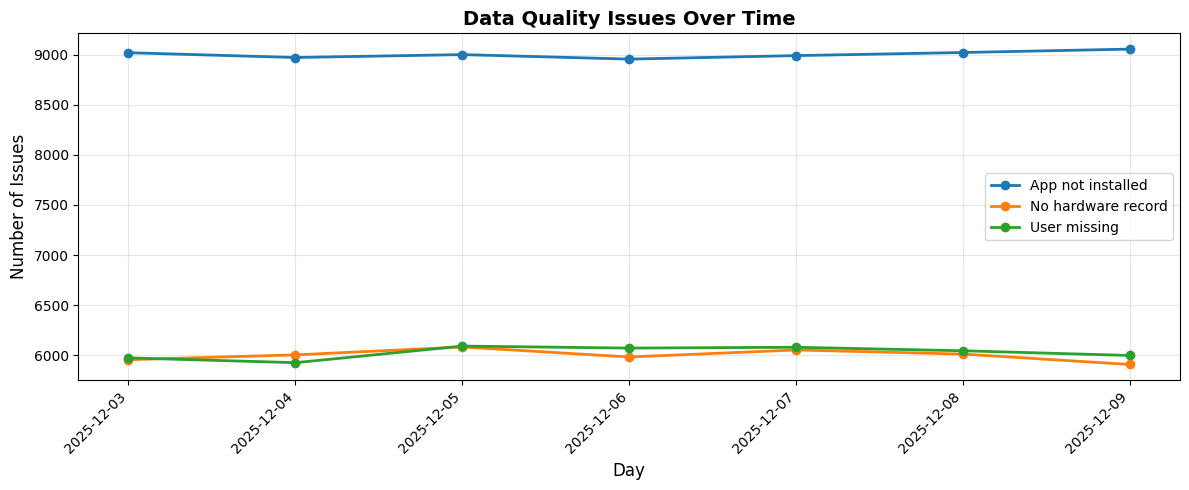

In [41]:
# Convert to pandas only for visualization
pdf_dq = dq_summary.toPandas()

plt.figure(figsize=(12, 5))
plt.plot(pdf_dq["day"], pdf_dq["session_app_not_installed"],
         marker="o", linewidth=2, label="App not installed")
plt.plot(pdf_dq["day"], pdf_dq["session_no_hardware"],
         marker="o", linewidth=2, label="No hardware record")
plt.plot(pdf_dq["day"], pdf_dq["session_user_missing"],
         marker="o", linewidth=2, label="User missing")
plt.xticks(rotation=45, ha='right')
plt.title("Data Quality Issues Over Time", fontsize=14, fontweight='bold')
plt.ylabel("Number of Issues", fontsize=12)
plt.xlabel("Day", fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Flat lines across all days. The "app not installed" stays at 9k, the other two at 6k. No improvement, no degradation - this is baked into the data pipeline.

**Conclusions:**
- Check 1 (app not installed) is the biggest issue - consistent ~9k violations
- Checks 2 & 3 (hardware/user missing) are also problematic at ~6k each
- These are systematic pipeline issues, not data corruption
- Recommend investigating the timing/sequencing of snapshot captures vs session logging


# Task 2 - Montana JSON Analysis

Analyzing Google Maps locations in Montana using pure Spark (no pandas in processing).

In [42]:
path2 = "data/meta-Montana.json"

raw_df = spark.read.json(path2)

print(f"Total venues: {raw_df.count()}")
print("\nSchema:")
raw_df.printSchema()

raw_df.select("name", "category", "avg_rating", "num_of_reviews").show(5, truncate=False, vertical=True)

Total venues: 21680

Schema:
root
 |-- MISC: struct (nullable = true)
 |    |-- Accessibility: array (nullable = true)
 |    |    |-- element: string (containsNull = true)
 |    |-- Activities: array (nullable = true)
 |    |    |-- element: string (containsNull = true)
 |    |-- Amenities: array (nullable = true)
 |    |    |-- element: string (containsNull = true)
 |    |-- Atmosphere: array (nullable = true)
 |    |    |-- element: string (containsNull = true)
 |    |-- Crowd: array (nullable = true)
 |    |    |-- element: string (containsNull = true)
 |    |-- Dining options: array (nullable = true)
 |    |    |-- element: string (containsNull = true)
 |    |-- From the business: array (nullable = true)
 |    |    |-- element: string (containsNull = true)
 |    |-- Health & safety: array (nullable = true)
 |    |    |-- element: string (containsNull = true)
 |    |-- Health and safety: array (nullable = true)
 |    |    |-- element: string (containsNull = true)
 |    |-- Highlight

21,680 venues in Montana. Schema shows categories as arrays (venues can be multiple types), plus ratings, reviews, coordinates, hours, and relative_results (related venues).

Mix of businesses - truck shop, ranch, repair services, salon, plumbing supply. Ratings vary (3.0 to 5.0), review counts are low for most (2-38).

## a. EDA - Most Popular and Highest Rated Categories

In [43]:
# Explode categories
df_with_categories = raw_df.withColumn(
    "category_exploded",
    F.explode(
        F.when(F.col("category").isNotNull(), F.col("category"))
        .otherwise(F.array())
    )
)

print(f"Rows after exploding categories: {df_with_categories.count()}")
df_with_categories.select("name", "category_exploded", "avg_rating").show(5, truncate=False, vertical=True)

Rows after exploding categories: 46526
-RECORD 0--------------------------------------------
 name              | Big Sky Truck & Equipment, Inc. 
 category_exploded | Truck accessories store         
 avg_rating        | 3.0                             
-RECORD 1--------------------------------------------
 name              | Big Sky Truck & Equipment, Inc. 
 category_exploded | Diesel engine dealer            
 avg_rating        | 3.0                             
-RECORD 2--------------------------------------------
 name              | Big Sky Truck & Equipment, Inc. 
 category_exploded | Used auto parts store           
 avg_rating        | 3.0                             
-RECORD 3--------------------------------------------
 name              | Wheelbarrow Creek Ranch         
 category_exploded | Ranch                           
 avg_rating        | 5.0                             
-RECORD 4--------------------------------------------
 name              | Montana Saws          

Top 15 most popular categories:
-RECORD 0---------------------------------
 category_exploded | Restaurant           
 count             | 1151                 
-RECORD 1---------------------------------
 category_exploded | Bar                  
 count             | 706                  
-RECORD 2---------------------------------
 category_exploded | Gas station          
 count             | 666                  
-RECORD 3---------------------------------
 category_exploded | Tourist attraction   
 count             | 576                  
-RECORD 4---------------------------------
 category_exploded | Campground           
 count             | 482                  
-RECORD 5---------------------------------
 category_exploded | Auto repair shop     
 count             | 480                  
-RECORD 6---------------------------------
 category_exploded | Coffee shop          
 count             | 477                  
-RECORD 7---------------------------------
 category_exploded | F

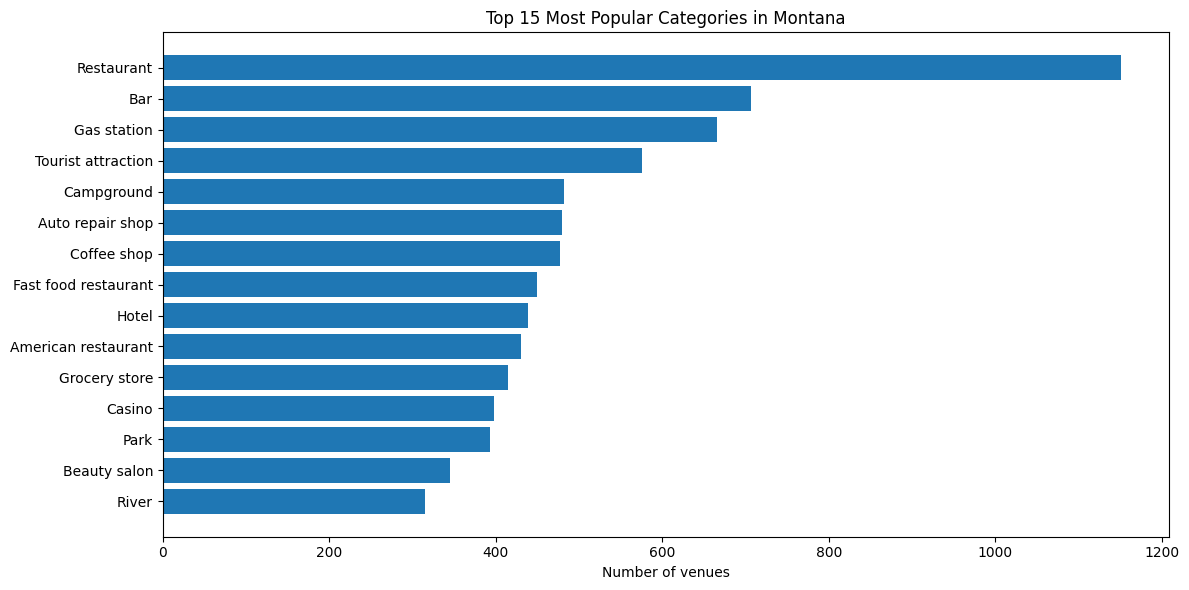

In [44]:
# Most popular categories
category_counts = df_with_categories.groupBy("category_exploded").agg(
    F.count("*").alias("count")
).orderBy(F.desc("count")).limit(15)

print("Top 15 most popular categories:")
category_counts.show(truncate=False, vertical=True)

pdf_cat_counts = category_counts.toPandas()

plt.figure(figsize=(12, 6))
plt.barh(pdf_cat_counts["category_exploded"], pdf_cat_counts["count"])
plt.gca().invert_yaxis()
plt.xlabel("Number of venues")
plt.title("Top 15 Most Popular Categories in Montana")
plt.tight_layout()
plt.show()

Restaurant dominates with 1,150+ venues - makes sense, everyone needs food. Bar (706) and Gas station (666) are strong too - car culture + social drinking. Tourist attraction (576) and Campground (482) show Montana's outdoor/tourism economy. Interesting that Casino ranks #11 - Montana has a lot of gambling apparently.

The top categories match what you'd expect in a rural/tourism state: food, fuel, lodging, outdoor recreation.


In [45]:
# Highest rated categories
min_venues = 20

category_ratings = df_with_categories.filter(
    F.col("avg_rating").isNotNull()
).groupBy("category_exploded").agg(
    F.count("*").alias("n_venues"),
    F.avg("avg_rating").alias("avg_rating"),
    F.expr("percentile_approx(avg_rating, 0.5)").alias("median_rating")
).filter(
    F.col("n_venues") >= min_venues
).orderBy(F.desc("avg_rating")).limit(15)

print(f"Top 15 highest rated categories (min {min_venues} venues):")
category_ratings.show(truncate=False, vertical=True)

Top 15 highest rated categories (min 20 venues):
-RECORD 0----------------------------------------------
 category_exploded | Chiropractor                      
 n_venues          | 79                                
 avg_rating        | 4.867088607594937                 
 median_rating     | 5.0                               
-RECORD 1----------------------------------------------
 category_exploded | Pottery store                     
 n_venues          | 21                                
 avg_rating        | 4.847619047619047                 
 median_rating     | 4.9                               
-RECORD 2----------------------------------------------
 category_exploded | Raft trip outfitter               
 n_venues          | 30                                
 avg_rating        | 4.846666666666666                 
 median_rating     | 4.9                               
-RECORD 3----------------------------------------------
 category_exploded | Photographer                      

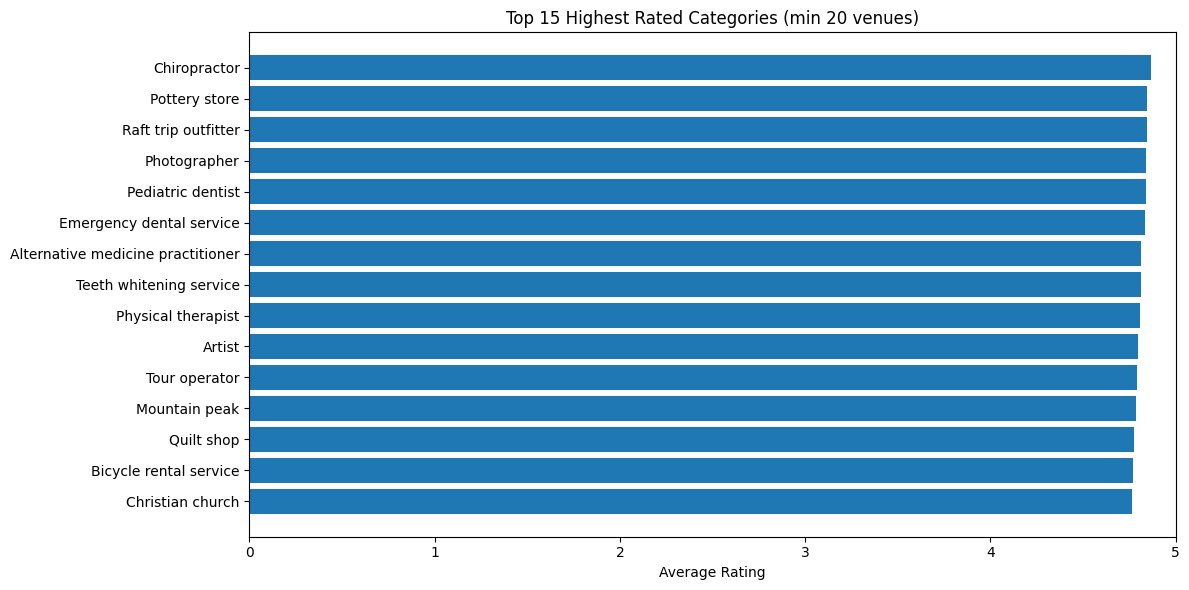

In [46]:
pdf_ratings = category_ratings.toPandas()

plt.figure(figsize=(12, 6))
plt.barh(pdf_ratings["category_exploded"], pdf_ratings["avg_rating"])
plt.gca().invert_yaxis()
plt.xlabel("Average Rating")
plt.title(f"Top 15 Highest Rated Categories (min {min_venues} venues)")
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

Healthcare dominates the top ratings - Chiropractor (4.87), Pediatric dentist (4.84), Emergency dental (4.83), Physical therapist (4.81). People really appreciate good medical care.

Creative/outdoor categories also score high: Pottery store (4.85), Raft trip outfitter (4.85), Photographer (4.84), Artist (4.80), Mountain peak (4.78).

Interesting pattern: specialty/niche services get better ratings than mass-market ones. Compare this to the "most popular" chart - Restaurant and Bar (popular) probably have lower avg ratings due to volume and variety. These high-rated categories are smaller, more specialized, and people only review them when they have strong positive experiences.

Christian church at #15 with 4.76 is notable - community/spiritual venues scoring well.


## b. Nightlife Analysis (9pm-6am): Weekends vs Weekdays

In [47]:
raw_df.select("hours").show(5, truncate=False)

+----------------------------------------------------------------------------------------------------------------------------------------------------+
|hours                                                                                                                                               |
+----------------------------------------------------------------------------------------------------------------------------------------------------+
|[[Thursday, 8AM–5PM], [Friday, 8AM–5PM], [Saturday, Closed], [Sunday, Closed], [Monday, 8AM–5PM], [Tuesday, 8AM–5PM], [Wednesday, 8AM–5PM]]         |
|NULL                                                                                                                                                |
|[[Thursday, 9AM–6PM], [Friday, 9AM–6PM], [Saturday, 9AM–5PM], [Sunday, Closed], [Monday, Closed], [Tuesday, 9AM–6PM], [Wednesday, 9AM–6PM]]         |
|[[Thursday, 10AM–9PM], [Friday, 10AM–9PM], [Saturday, 10AM–9PM], [Sunday, 11AM–6PM], [Monday,

In [48]:
# Define UDF to check if venue is open during nightlife hours
# Simple approach: check if the hours string mentions late-night times (9pm-12am)

@F.udf(returnType=BooleanType())
def is_nightlife_weekday_udf(hours):
    # Check if venue is open 9pm-6am on weekdays (Mon-Thu)
    if not hours:
        return False

    weekdays = ["Monday", "Tuesday", "Wednesday", "Thursday"]

    for day_hours in hours:
        if len(day_hours) != 2:
            continue

        day, hours_str = day_hours
        if day not in weekdays:
            continue

        hours_str = str(hours_str).lower()

        if "24 hours" in hours_str or "open 24 hours" in hours_str:
            return True

        if "closed" in hours_str:
            continue

        if "9pm" in hours_str or "10pm" in hours_str or "11pm" in hours_str or "12am" in hours_str:
            return True

    return False

In [49]:
@F.udf(returnType=BooleanType())
def is_nightlife_weekend_udf(hours):
    # Check if venue is open 9pm-6am on weekends (Fri-Sun)
    if not hours:
        return False
    weekends = ["Friday", "Saturday", "Sunday"]
    for day_hours in hours:
        if len(day_hours) != 2:
            continue
        day, hours_str = day_hours
        if day not in weekends:
            continue
        hours_str = str(hours_str).lower()
        if "24 hours" in hours_str or "open 24 hours" in hours_str:
            return True
        if "closed" in hours_str:
            continue
        if "9pm" in hours_str or "10pm" in hours_str or "11pm" in hours_str or "12am" in hours_str:
            return True
    return False

In [50]:
df_nightlife = raw_df.withColumn(
    "is_nightlife_weekday",
    is_nightlife_weekday_udf(F.col("hours"))
).withColumn(
    "is_nightlife_weekend",
    is_nightlife_weekend_udf(F.col("hours"))
)

print("Sample with nightlife flags:")
df_nightlife.select("name", "is_nightlife_weekday", "is_nightlife_weekend").show(5, truncate=False, vertical=True)

Sample with nightlife flags:
-RECORD 0-----------------------------------------------
 name                 | Big Sky Truck & Equipment, Inc. 
 is_nightlife_weekday | false                           
 is_nightlife_weekend | false                           
-RECORD 1-----------------------------------------------
 name                 | Wheelbarrow Creek Ranch         
 is_nightlife_weekday | false                           
 is_nightlife_weekend | false                           
-RECORD 2-----------------------------------------------
 name                 | Montana Saws                    
 is_nightlife_weekday | false                           
 is_nightlife_weekend | false                           
-RECORD 3-----------------------------------------------
 name                 | Regis Salon                     
 is_nightlife_weekday | true                            
 is_nightlife_weekend | true                            
-RECORD 4-----------------------------------------------
 n

UDFs working - Regis Salon flagged as nightlife (open late both weekdays and weekends), while truck shop, ranch, and plumbing supply close early. Counting totals.


In [51]:
# Count nightlife venues
nightlife_counts = df_nightlife.agg(
    F.sum(F.col("is_nightlife_weekday").cast("int")).alias("weekday_nightlife"),
    F.sum(F.col("is_nightlife_weekend").cast("int")).alias("weekend_nightlife")
)

print("Nightlife venue counts:")
nightlife_counts.show(truncate=False, vertical=True)

Nightlife venue counts:
-RECORD 0-----------------
 weekday_nightlife | 3717 
 weekend_nightlife | 3901 



~3,700 venues open late on weekdays vs ~3,900 on weekends. The difference is smaller than expected - only about 200 more weekend venues. Montana's nightlife is more active than I thought for a rural state, and it's fairly consistent throughout the week.

Visualizing the comparison.


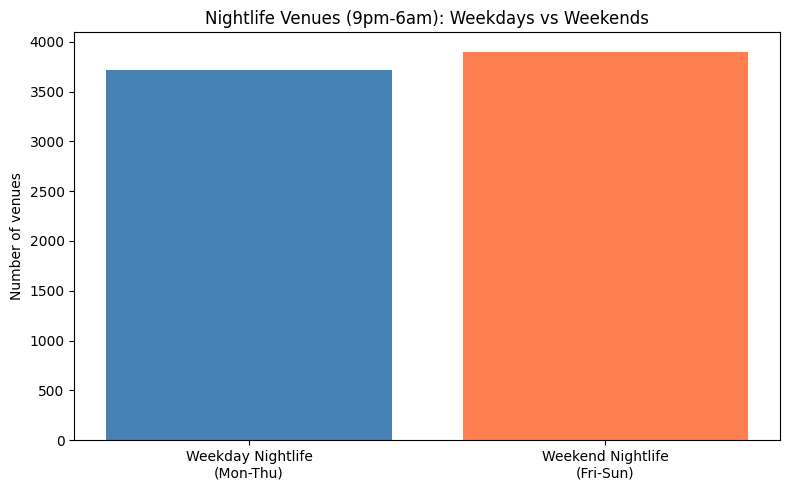

In [52]:
pdf_nightlife = nightlife_counts.toPandas()

plt.figure(figsize=(8, 5))
plt.bar(
    ["Weekday Nightlife\n(Mon-Thu)", "Weekend Nightlife\n(Fri-Sun)"],
    [pdf_nightlife["weekday_nightlife"][0], pdf_nightlife["weekend_nightlife"][0]],
    color=["steelblue", "coral"]
)
plt.ylabel("Number of venues")
plt.title("Nightlife Venues (9pm-6am): Weekdays vs Weekends")
plt.tight_layout()
plt.show()

Weekend slightly edges out weekdays (3,900 vs 3,700). Montana has consistent late-night needs - gas stations, restaurants, and services staying open for travelers.


### Top Nightlife Categories


In [53]:
# Filter nightlife venues and explode categories
nightlife_only = df_nightlife.filter(
    F.col("is_nightlife_weekday") | F.col("is_nightlife_weekend")
)

nightlife_with_cats = nightlife_only.withColumn(
    "category_exploded",
    F.explode(
        F.when(F.col("category").isNotNull(), F.col("category"))
        .otherwise(F.array())
    )
)

In [54]:
# Count top nightlife categories
nightlife_cat_counts = nightlife_with_cats.groupBy("category_exploded").agg(
    F.count("*").alias("count")
).orderBy(F.desc("count")).limit(15)

print("Top 15 nightlife categories:")
nightlife_cat_counts.show(truncate=False, vertical=True)

Top 15 nightlife categories:
-RECORD 0---------------------------------
 category_exploded | Restaurant           
 count             | 589                  
-RECORD 1---------------------------------
 category_exploded | Gas station          
 count             | 413                  
-RECORD 2---------------------------------
 category_exploded | Fast food restaurant 
 count             | 315                  
-RECORD 3---------------------------------
 category_exploded | Bar                  
 count             | 292                  
-RECORD 4---------------------------------
 category_exploded | Grocery store        
 count             | 264                  
-RECORD 5---------------------------------
 category_exploded | American restaurant  
 count             | 229                  
-RECORD 6---------------------------------
 category_exploded | Convenience store    
 count             | 223                  
-RECORD 7---------------------------------
 category_exploded | Pizz

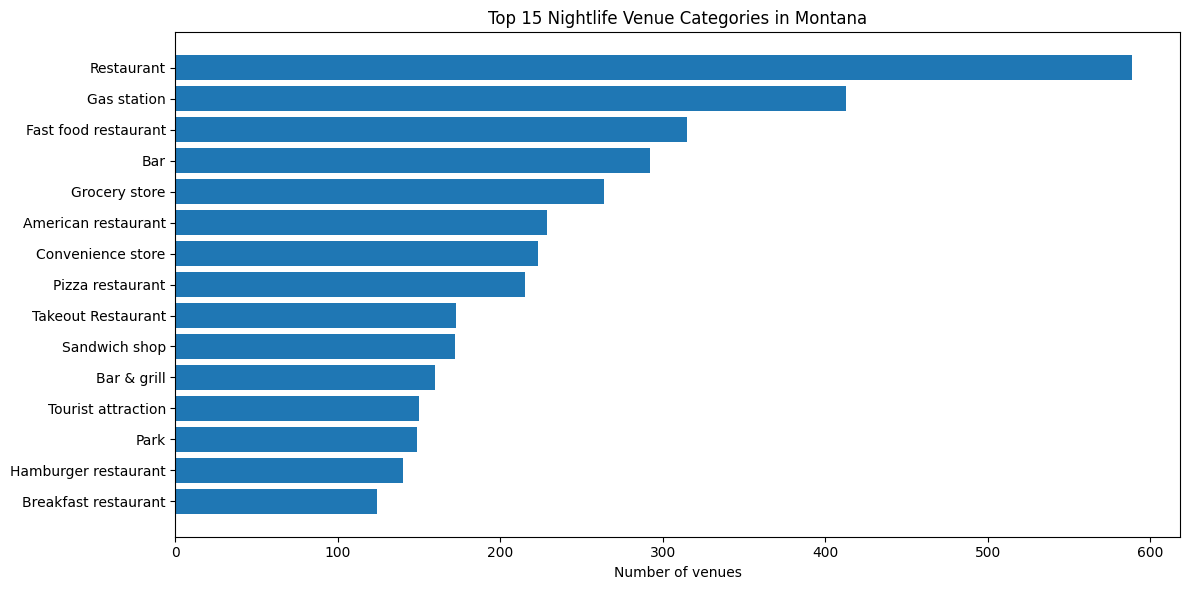

In [55]:
pdf_nightlife_cats = nightlife_cat_counts.toPandas()

plt.figure(figsize=(12, 6))
plt.barh(pdf_nightlife_cats["category_exploded"], pdf_nightlife_cats["count"])
plt.gca().invert_yaxis()
plt.xlabel("Number of venues")
plt.title("Top 15 Nightlife Venue Categories in Montana")
plt.tight_layout()
plt.show()

Restaurant dominates nightlife (589 venues), followed by gas stations and fast food. Mix of necessity (fuel, groceries) and social (bars, restaurants).


## c. Why "relative_results" are relative? Feature/category connections


In [56]:
raw_df.select("gmap_id", "relative_results").show(5, truncate=False, vertical=True)

-RECORD 0---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
 gmap_id          | 0x535dc557d042b1f3:0xc419b6f55435c7de                                                                                                                                                               
 relative_results | [0x535dcbcf35d19b91:0xa0d0e7f0f42a94b6, 0x535dcff3914c2049:0x14bb0d04b036a1e6, 0x535dcf9353c63d19:0xdded1a1da3db136d, 0x535dce67845bae99:0x5935322a4d6efdb4, 0x535ddab33551f597:0xc6c66fe54294a498] 
-RECORD 1---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
 gmap_id          | 0x535c2690c357f3bd:0x272620bb52fecf11                                                                           

Each venue links to other venues. These are just IDs - need to join back to get full venue info.

In [57]:
# Create edges DataFrame - explode relative_results
edges_df = raw_df.select(
    F.col("gmap_id").alias("src_id"),
    F.col("name").alias("src_name"),
    F.col("category").alias("src_category"),
    F.col("latitude").alias("src_lat"),
    F.col("longitude").alias("src_lng"),
    F.explode(
        F.when(F.col("relative_results").isNotNull(), F.col("relative_results"))
        .otherwise(F.array())
    ).alias("dst_id")
)

print(f"Total relationship edges: {edges_df.count()}")
edges_df.show(5, truncate=False, vertical=True)

Total relationship edges: 85524
-RECORD 0------------------------------------------------------------------------------
 src_id       | 0x535dc557d042b1f3:0xc419b6f55435c7de                                  
 src_name     | Big Sky Truck & Equipment, Inc.                                        
 src_category | [Truck accessories store, Diesel engine dealer, Used auto parts store] 
 src_lat      | 46.9335221                                                             
 src_lng      | -114.10651469999999                                                    
 dst_id       | 0x535dcbcf35d19b91:0xa0d0e7f0f42a94b6                                  
-RECORD 1------------------------------------------------------------------------------
 src_id       | 0x535dc557d042b1f3:0xc419b6f55435c7de                                  
 src_name     | Big Sky Truck & Equipment, Inc.                                        
 src_category | [Truck accessories store, Diesel engine dealer, Used auto parts store] 


85,524 relationship edges total. Big Sky Truck links to 5 other places. Now joining to get details about the destination venues.


In [58]:
# Join to get destination venue info
edges_with_dst = edges_df.join(
    raw_df.select(
        F.col("gmap_id").alias("dst_gmap_id"),
        F.col("name").alias("dst_name"),
        F.col("category").alias("dst_category"),
        F.col("latitude").alias("dst_lat"),
        F.col("longitude").alias("dst_lng")
    ),
    edges_df["dst_id"] == F.col("dst_gmap_id"),
    how="inner"
)

print(f"Edges with both venues info: {edges_with_dst.count()}")
edges_with_dst.show(3, truncate=False, vertical=True)

Edges with both venues info: 52930
-RECORD 0------------------------------------------------------------------------------------------------------------------
 src_id       | 0x535dc557d042b1f3:0xc419b6f55435c7de                                                                      
 src_name     | Big Sky Truck & Equipment, Inc.                                                                            
 src_category | [Truck accessories store, Diesel engine dealer, Used auto parts store]                                     
 src_lat      | 46.9335221                                                                                                 
 src_lng      | -114.10651469999999                                                                                        
 dst_id       | 0x535dcf9353c63d19:0xdded1a1da3db136d                                                                      
 dst_gmap_id  | 0x535dcf9353c63d19:0xdded1a1da3db136d                                            

52,930 edges with complete data (some destinations weren't in our dataset).

Big Sky Truck -> Rocky Mountain Truck (both truck-related, 3km apart) <br>
Big Sky Truck -> Six Robblees' Inc (trailer supplies, close by) <br>
Wheelbarrow Creek Ranch → Burnt Fork Ranch (both ranches, ~14km apart)

Pattern emerging: similar businesses that are geographically close. Testing this statistically.

### Category Overlap Analysis


In [59]:
@F.udf(returnType=IntegerType())
def category_overlap_udf(cat1, cat2):
    # Calculate number of shared categories
    if not cat1 or not cat2:
        return 0
    set1 = set(cat1)
    set2 = set(cat2)
    return len(set1 & set2)

In [60]:
# Calculate category overlap
edges_with_overlap = edges_with_dst.withColumn(
    "shared_categories",
    category_overlap_udf(F.col("src_category"), F.col("dst_category"))
).withColumn(
    "has_common_category",
    F.col("shared_categories") > 0
)

In [61]:
# Calculate statistics
overlap_stats = edges_with_overlap.agg(
    F.count("*").alias("total_edges"),
    F.sum(F.col("has_common_category").cast("int")).alias("edges_with_common_cat"),
    F.avg(F.col("shared_categories").cast("double")).alias("avg_shared_categories")
)

print("Category overlap statistics:")
overlap_stats.show(truncate=False, vertical=True)

Category overlap statistics:
-RECORD 0-----------------------------------
 total_edges           | 52930              
 edges_with_common_cat | 33843              
 avg_shared_categories | 0.8695635745324013 



Strong signal here.


In [62]:
# Calculate percentage
overlap_pct_df = overlap_stats.select(
    (F.col("edges_with_common_cat") / F.col("total_edges") * 100).alias("pct_with_common_category")
)

print("Percentage with common category:")
overlap_pct_df.show(truncate=False, vertical=True)

# Extract value for printing
overlap_pct = overlap_pct_df.collect()[0]["pct_with_common_category"]
print(f"\n{overlap_pct:.1f}% of related venues share at least one category")

Percentage with common category:
-RECORD 0-------------------------------------
 pct_with_common_category | 63.93916493481957 


63.9% of related venues share at least one category


That's evidence Google's algorithm heavily weights category similarity. If you're at a restaurant, it suggests other restaurants.

Now checking geographic proximity.


### Geographic Distance Analysis

In [63]:
@F.udf(returnType=DoubleType())
def haversine_udf(lat1, lon1, lat2, lon2):
    # Calculate distance between two points in km
    if not all([lat1, lon1, lat2, lon2]):
        return None

    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c

In [64]:
# Calculate distances
edges_with_distance = edges_with_overlap.withColumn(
    "distance_km",
    haversine_udf(
        F.col("src_lat"), F.col("src_lng"),
        F.col("dst_lat"), F.col("dst_lng")
    )
).filter(F.col("distance_km").isNotNull())

print("Distance statistics:")
edges_with_distance.select("distance_km").summary().show()

Distance statistics:
+-------+------------------+
|summary|       distance_km|
+-------+------------------+
|  count|             52930|
|   mean| 6.326241538157176|
| stddev|12.600044740833962|
|    min|               0.0|
|    25%|0.6725127835553713|
|    50%|2.2619606010083197|
|    75%| 6.027090999166892|
|    max|327.99207743777436|
+-------+------------------+



In [65]:
# Calculate statistics
distance_stats = edges_with_distance.select("distance_km").agg(
    F.expr("percentile_approx(distance_km, 0.5)").alias("median_km"),
    F.mean("distance_km").alias("mean_km"),
    F.min("distance_km").alias("min_km"),
    F.max("distance_km").alias("max_km")
)

print("Distance statistics (Spark calculation):")
distance_stats.show(truncate=False, vertical=True)

# Get median for visualization
median_km = distance_stats.collect()[0]["median_km"]

Distance statistics (Spark calculation):
-RECORD 0-----------------------
 median_km | 2.2619606010083197 
 mean_km   | 6.326241538157176  
 min_km    | 0.0                
 max_km    | 327.99207743777436 



Mean distance is 6.3 km but that's skewed by outliers (max is 328 km!). Median of 2.3 km is more meaningful - half of all related venue pairs are within ~2 km of each other.

Visualizing the distribution.


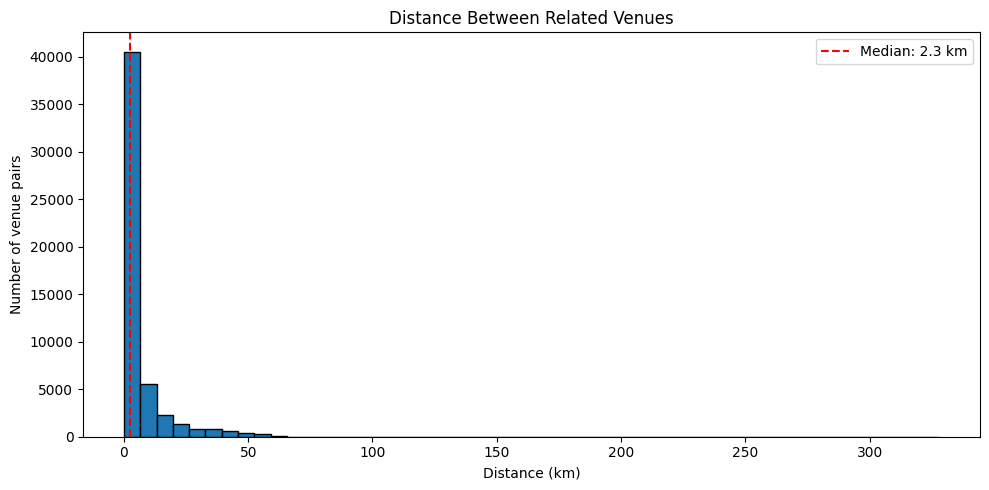


Median distance between related venues: 2.3 km


In [66]:
pdf_dist = edges_with_distance.select("distance_km").toPandas()

plt.figure(figsize=(10, 5))
plt.hist(pdf_dist["distance_km"], bins=50, edgecolor='black')
plt.xlabel("Distance (km)")
plt.ylabel("Number of venue pairs")
plt.title("Distance Between Related Venues")
plt.axvline(median_km, color='red', linestyle='--',
            label=f'Median: {median_km:.1f} km')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nMedian distance between related venues: {median_km:.1f} km")

Massive spike near 0 km - tons of venues recommend their immediate neighbors. The median line at 2.3 km shows most recommendations are very local. Long tail extends to 300+ km but those are rare.


**Why "relative_results" are relative:**

Two factors drive Google's recommendations:

1. **Category Similarity** (63.9% share categories): Algorithm matches business types
2. **Geographic Proximity** (median 2.3 km): Recommendations are locally relevant

Google shows similar business types that are actually nearby enough to visit.


## d. Find top 5 closest points using coordinates

In [67]:
# Check coordinates availability
coords_available = raw_df.filter(
    F.col("latitude").isNotNull() & F.col("longitude").isNotNull()
).count()

print(f"Venues with coordinates: {coords_available} out of {raw_df.count()}")

Venues with coordinates: 21680 out of 21680


All venues have coordinates - good data quality. Cross joining to create all possible pairs.


In [68]:
# Create venues DataFrame with coordinates
venues_with_coords = raw_df.filter(
    F.col("latitude").isNotNull() & F.col("longitude").isNotNull()
).select(
    F.col("gmap_id").alias("id"),
    F.col("name"),
    F.col("category"),
    F.col("latitude"),
    F.col("longitude")
)

print(f"Working with {venues_with_coords.count()} venues")

Working with 21680 venues


In [69]:
# Cross join to create all pairs
venue_pairs = venues_with_coords.alias("a").crossJoin(
    venues_with_coords.alias("b")
).filter(
    F.col("a.id") != F.col("b.id")
)

print(f"Total venue pairs: {venue_pairs.count()}")

Total venue pairs: 470000428


470 million pairs to process. Calculating haversine distances for all of them.


In [70]:
# Calculate distances for all pairs
pairs_with_distance = venue_pairs.withColumn(
    "distance_km",
    haversine_udf(
        F.col("a.latitude"), F.col("a.longitude"),
        F.col("b.latitude"), F.col("b.longitude")
    )
).select(
    F.col("a.id").alias("src_id"),
    F.col("a.name").alias("src_name"),
    F.col("a.category").alias("src_category"),
    F.col("b.id").alias("dst_id"),
    F.col("b.name").alias("dst_name"),
    F.col("b.category").alias("dst_category"),
    "distance_km"
)

print("Sample pairs with distances:")
pairs_with_distance.orderBy("distance_km").show(5, truncate=False, vertical=True)

Sample pairs with distances:


-RECORD 0-------------------------------------------------------------------------------------------------------------------------------------------
 src_id       | 0x534355720f582343:0x27e7065bbd59b03e                                                                                               
 src_name     | Sell Car For Cash Helena                                                                                                            
 src_category | [Towing service, Auto broker, Auto wrecker, Car dealer, Junkyard, Salvage yard, Truck dealer, Used car dealer, Used truck dealer]   
 dst_id       | 0x536650cf7ee15371:0xed5b4b417bf4b290                                                                                               
 dst_name     | Flathead Luxury Limousine                                                                                                           
 dst_category | [Limousine service, Service establishment, Transportation service, Wedding service]       

Distance 0.0 km means exact same coordinates - different businesses at the same address (like doctors in a medical building, or businesses sharing a location).

Using window functions to get top 5 nearest for each venue.

In [71]:
# Find top 5 nearest neighbors using window functions
w = Window.partitionBy("src_id").orderBy("distance_km")

nearest_neighbors = pairs_with_distance.withColumn(
    "rank",
    F.row_number().over(w)
).filter(
    F.col("rank") <= 5
)

print(f"Total nearest neighbor relationships (5 per venue): {nearest_neighbors.count()}")
nearest_neighbors.show(10, truncate=False, vertical=True)

Total nearest neighbor relationships (5 per venue): 107670


-RECORD 0-------------------------------------------------------------------------------------------------------------------------------------
 src_id       | 0x4107db74133f3a47:0x2586b3337e33a5ba                                                                                         
 src_name     | Blue Ribbon of Montana                                                                                                        
 src_category | [Gift shop]                                                                                                                   
 dst_id       | 0x5342382244886d93:0x974459ca853b707                                                                                          
 dst_name     | City Brew Coffee                                                                                                              
 dst_category | [Coffee shop, Cafe]                                                                                                           

107,670 relationships total (21,534 venues x 5 neighbors each, some venues might have fewer).

### BONUS: What kind of venues are usually close to each other?


In [72]:
# Explode categories for both source and destination
nn_exploded = nearest_neighbors.withColumn(
    "src_cat",
    F.explode(
        F.when(F.col("src_category").isNotNull(), F.col("src_category"))
        .otherwise(F.array())
    )
).withColumn(
    "dst_cat",
    F.explode(
        F.when(F.col("dst_category").isNotNull(), F.col("dst_category"))
        .otherwise(F.array())
    )
)

In [73]:
# Make pairs undirected to avoid duplicates
pairs_undirected = nn_exploded.withColumn(
    "cat_a", F.least("src_cat", "dst_cat")
).withColumn(
    "cat_b", F.greatest("src_cat", "dst_cat")
)

# Remove same-category pairs
pairs_cross_category = pairs_undirected.filter(
    F.col("cat_a") != F.col("cat_b")
)

# Aggregate
category_pairs = pairs_cross_category.groupBy("cat_a", "cat_b").agg(
    F.count("*").alias("count")
).orderBy(F.desc("count")).limit(20)

print("Top 20 category pairs that are geographically close:")
category_pairs.show(20, truncate=False, vertical=True)

Top 20 category pairs that are geographically close:


-RECORD 0---------------------
 cat_a | Bar                  
 cat_b | Restaurant           
 count | 675                  
-RECORD 1---------------------
 cat_a | Gas station          
 cat_b | Restaurant           
 count | 618                  
-RECORD 2---------------------
 cat_a | Fast food restaurant 
 cat_b | Restaurant           
 count | 494                  
-RECORD 3---------------------
 cat_a | Casino               
 cat_b | Restaurant           
 count | 408                  
-RECORD 4---------------------
 cat_a | Coffee shop          
 cat_b | Restaurant           
 count | 402                  
-RECORD 5---------------------
 cat_a | Convenience store    
 cat_b | Gas station          
 count | 400                  
-RECORD 6---------------------
 cat_a | Casino               
 cat_b | Gas station          
 count | 399                  
-RECORD 7---------------------
 cat_a | Hotel                
 cat_b | Restaurant           
 count | 397                  
-RECORD 

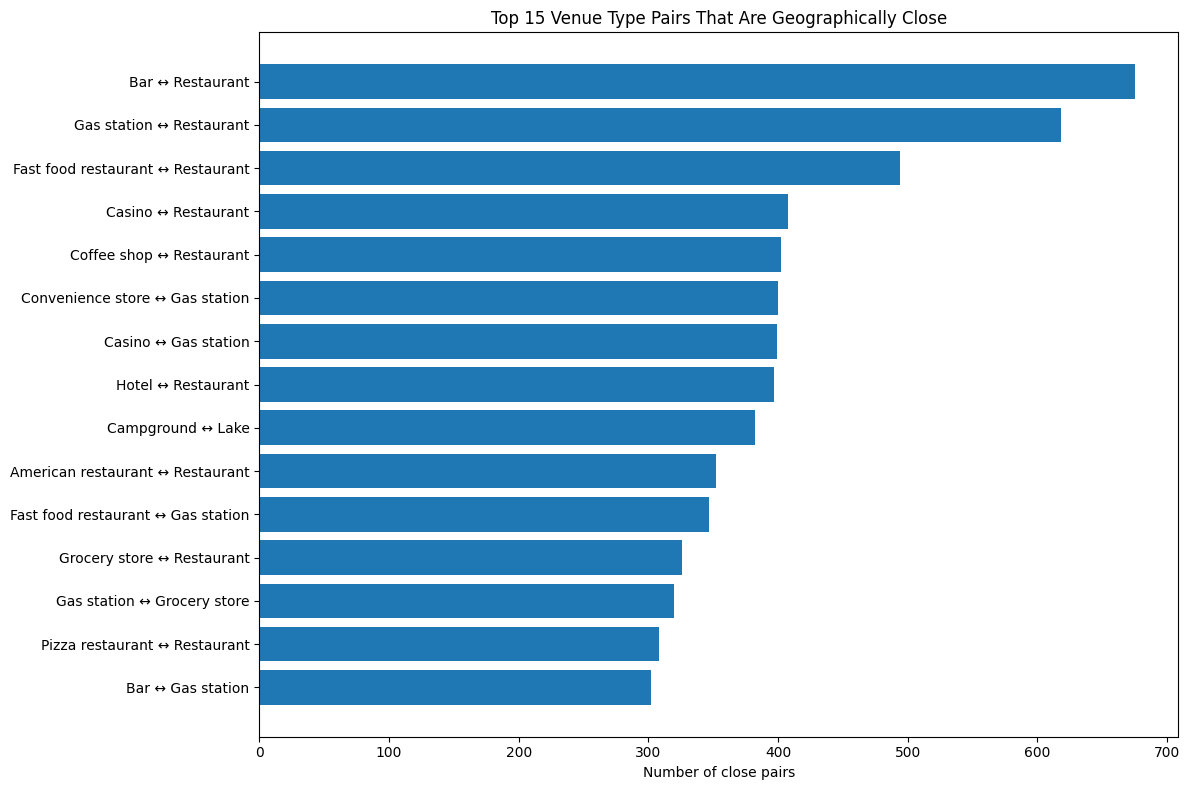

In [74]:
pdf_pairs = category_pairs.limit(15).toPandas()

plt.figure(figsize=(12, 8))
pair_labels = pdf_pairs["cat_a"] + " ↔ " + pdf_pairs["cat_b"]
plt.barh(pair_labels, pdf_pairs["count"])
plt.gca().invert_yaxis()
plt.xlabel("Number of close pairs")
plt.title("Top 15 Venue Type Pairs That Are Geographically Close")
plt.tight_layout()
plt.show()